# ukpyn - Official Launch Demo

**Python client for UK Power Networks Open Data**

```
pip install ukpyn
```

133+ datasets | 10 orchestrators | async-first | geospatial-ready

---
## 1. Your First Query - Three Lines of Code

No dataset IDs to memorise. No URL construction. No pagination logic.

In [212]:
from ukpyn import ltds

# Observed peak demand at every primary substation in South East England
observed = ltds.get_table_3a(licence_area="SPN", limit=5)

print(f"Total records available: {observed.total_count}")
print(f"Returned: {len(observed.records)}")
print()

rec = observed.records[0]
for key, val in sorted(rec.fields.items()):
    print(f"  {key}: {val}")

Total records available: 596
Returned: 5

  firm_capacity_mw: 22.5
  forecast_m_d_mw_25_26: 7.0
  forecast_m_d_mw_26_27: 7.0
  forecast_m_d_mw_27_28: 6.9
  forecast_m_d_mw_28_29: 7.2
  forecast_m_d_mw_29_30: 7.4
  functional_location: SPN-S000000008609
  gridsupplypoint: Beddington
  licencearea: South Eastern Power Networks (SPN)
  maximum_demand_24_25_mw: 6.3
  maximum_demand_24_25_pf: 0.98
  minimum_load_scaling_factor: None
  season: Winter
  substation: Addington Grid 11kV
  substation_mrid: _b82173e1-bb63-4a43-82c3-d65442c9eb0f
  unutilised_capacity_percent: 72.0


---
## 2. Ten Orchestrators - One for Every Domain

ukpyn organises datasets into **orchestrators** — themed modules with convenience methods.

In [213]:
from ukpyn.orchestrators import LTDSOrchestrator

orch = LTDSOrchestrator()
print("Available datasets:", orch.available_datasets)

Available datasets: ['table_1', 'circuit_data', 'table_2a', 'transformer_2w', 'table_2b', 'transformer_3w', 'table_3a', 'observed_demand', 'observed_peak_demand', 'table_3a_transposed', 'table_3b', 'forecast_demand', 'table_4a', 'fault_level_3ph', 'table_4b', 'fault_level_earth', 'table_5', 'generation', 'table_6', 'connection_interest', 'table_7', 'restrictions', 'table_8', 'fault_data', 'projects', 'infrastructure_projects', 'cim']


---
## 3. Facet Discovery - See What's Inside a Dataset

Every orchestrator can show you the **facets** (filterable categories) available on any dataset. This is useful for understanding what values exist before you query.

In [214]:
# Discover facets on the LTDS Table 3a dataset
facets = ltds.get_facets("table_3a")

print("Facet groups available on LTDS Table 3a:\n")
for group in facets.facets:
    print(f"  {group.name}")
    for facet in group.facets[:5]:  # show first 5 values per group
        print(f"    • {facet.name} ({facet.count:,} records)")
    if len(group.facets) > 5:
        print(f"    ... and {len(group.facets) - 5} more")
    print()

Facet groups available on LTDS Table 3a:

  licencearea
    • Eastern Power Networks (EPN) (1,110 records)
    • London Power Networks (LPN) (258 records)
    • South Eastern Power Networks (SPN) (596 records)

  gridsupplypoint
    • Acton Lane 22kV (2 records)
    • Amersham (14 records)
    • Barking 132kV (8 records)
    • Barking C 132kV (2 records)
    • Barking West 33kV (16 records)
    ... and 50 more

  substation
    • Abberton Grid 33kV (2 records)
    • Abbots Central Primary 11kV (2 records)
    • Aberdeen Pl A 11kV (2 records)
    • Aberdeen Pl B 11kV (2 records)
    • Acrows Primary 11kV (2 records)
    ... and 95 more

  season
    • Summer (982 records)
    • Winter (982 records)



---
## 4. Facet Filtering with `refine` - Precise, Fast Queries

Once you know the facets, use `refine` to filter at the API level — faster and cleaner than SQL WHERE clauses for categorical data.

> **Heads up:** Facet names come from the raw API (e.g. `licencearea`, `fuel_type`) — but convenience methods use Pythonic parameter names (e.g. `licence_area`). The orchestrator handles the mapping for you. When using `refine={}` directly, use the raw facet names.

In [215]:
# Step 1: See what fuel types are in the generation register
gen_facets = ltds.get_facets("table_5")

for group in gen_facets.facets:
    if group.name.lower() in ("fuel_type"):
        print("Fuel types in LTDS Table 5:\n")
        for f in group.facets:
            print(f"  {f.name:30s}  ({f.count:,} records)")
        break

Fuel types in LTDS Table 5:

  Photovoltaic (>=1MW)            (290 records)
  Other Generation (>=1MW)        (245 records)
  Energy Storage (>=1MW)          (104 records)
  Onshore Wind (>=1MW)            (43 records)
  Small CHP (>=1MW, <5MW)         (43 records)
  Medium CHP(>=5MW, <50MW)        (23 records)
  Large CHP (>=50MW)              (10 records)
  Offshore Wind (>=1MW)           (5 records)
  Photovoltaic                    (2 records)
  Unknown                         (2 records)
  CHP                             (1 records)
  Other Generation                (1 records)


In [217]:
# Step 2a: Convenience method — uses Pythonic parameter names
# licence_area="SPN" maps to refine["licencearea"] = "South Eastern Power Networks (SPN)" internally
solar_gen = ltds.get_table_5(licence_area="SPN", fuel_type="Small CHP")

print(f"CHP sites in SPN: {solar_gen.total_count}\n")
for rec in solar_gen.records:
    f = rec.fields
    gsp = f.get("gridsupplypoint", "?")
    cap = f.get("registered_capacity_mw", f.get("installedcapacity_mva", "?"))
    fuel = f.get("fuel_type", "?")
    print(f"  {str(gsp):35s}  {str(cap):>8} MVA  ({fuel})")

CHP sites in SPN: 8

  Beddington SGT                            1.1 MVA  (Small CHP (>=1MW, <5MW))
  Kingsnorth SGT                            1.3 MVA  (Small CHP (>=1MW, <5MW))
  Littlebrook SGT                           2.1 MVA  (Small CHP (>=1MW, <5MW))
  Sellindge SGT2 & 3 & Richborough SGT       1.2 MVA  (Small CHP (>=1MW, <5MW))
  Sellindge SGT2 & 3 & Richborough SGT       1.1 MVA  (Small CHP (>=1MW, <5MW))
  West Weybridge SGT                        1.6 MVA  (Small CHP (>=1MW, <5MW))
  Beddington SGT                            1.0 MVA  (Small CHP (>=1MW, <5MW))
  Bolney SGT                                1.2 MVA  (Small CHP (>=1MW, <5MW))


In [218]:
# Step 2b: Generic get() with raw refine — use exact facet names from get_facets()
solar_gen2 = ltds.get(
    "table_5",
    refine={"licencearea": "South Eastern Power Networks (SPN)"},
    where="fuel_type LIKE 'Photovoltaic%' OR fuel_type LIKE 'Energy Storage%'",
    limit=-1,
)

print(f"Photovoltaic + Energy Storage sites in SPN: {solar_gen2.total_count}\n")

pv = [
    r for r in solar_gen2.records if "Photovoltaic" in (r.fields.get("fuel_type") or "")
]
es = [
    r
    for r in solar_gen2.records
    if "Energy Storage" in (r.fields.get("fuel_type") or "")
]

for label, group in [("Photovoltaic", pv[:3]), ("Energy Storage", es[:3])]:
    print(f"  {label}:")
    for rec in group:
        f = rec.fields
        gsp = f.get("gridsupplypoint", "?")
        cap = f.get("registered_capacity_mw", f.get("installedcapacity_mva", "?"))
        print(f"    {str(gsp):35s}  {str(cap):>8} MVA")
    print()

Photovoltaic + Energy Storage sites in SPN: 119

  Photovoltaic:
    West Weybridge SGT                        1.3 MVA
    Beddington SGT                           16.8 MVA
    Bolney SGT                              105.8 MVA

  Energy Storage:
    Bolney SGT                              986.8 MVA
    Kemsley SGT1 & 2                         37.0 MVA
    Ninfield SGT                             17.9 MVA



---
## 5. Using AI

Can the project be used by AI

In [ ]:
"""
I want to use the ukpyn library to fetch the 33kv monthly timeseries of a circuit in the EPN area, convert it to a DataFrame, and create a line plot.\
Return me the code that accomplishes this task, including the DataFrame creation and the plotting steps.
"""

In [221]:
import matplotlib.pyplot as plt
import pandas as pd

from ukpyn.orchestrators import powerflow

# 1. Discover a 33kV circuit in EPN to pick one
circuits = powerflow.discover_circuits(voltage="33kv", licence_area="EPN", limit=10)
circuit_id = circuits.records[9].fields["ltds_line_name"]
print(f"Using circuit: {circuit_id}")

# 2. Fetch the 33kV monthly timeseries for that circuit
response = powerflow.get_circuit_timeseries(
    voltage="33kv",
    granularity="monthly",
    circuit_id=circuit_id,
    licence_area="EPN",
    limit=1000,
)

# 3. Convert to a DataFrame
df = pd.DataFrame([r.fields for r in response.records])
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").set_index("timestamp")
print(df.head())

Using circuit: lne_AYLE_ALDA_2
                          licence_area             grid_supply_point category  \
timestamp                                                                       
2023-01-01 00:00:00+00:00          EPN  AYLESBURY EAST GRID (0D8002)  circuit   
2023-02-01 00:00:00+00:00          EPN  AYLESBURY EAST GRID (0D8002)  circuit   
2023-03-01 00:00:00+00:00          EPN  AYLESBURY EAST GRID (0D8002)  circuit   
2023-04-01 00:00:00+00:00          EPN  AYLESBURY EAST GRID (0D8002)  circuit   
2023-05-01 00:00:00+00:00          EPN  AYLESBURY EAST GRID (0D8002)  circuit   

                            feeder_description   ltds_line_name  \
timestamp                                                         
2023-01-01 00:00:00+00:00  Arla Daries Primary  lne_AYLE_ALDA_2   
2023-02-01 00:00:00+00:00  Arla Daries Primary  lne_AYLE_ALDA_2   
2023-03-01 00:00:00+00:00  Arla Daries Primary  lne_AYLE_ALDA_2   
2023-04-01 00:00:00+00:00  Arla Daries Primary  lne_AYLE_ALDA_2   

In [222]:
df.describe()

,nominal_voltage,active_power_month_min_mw,active_power_month_mean_mw,active_power_month_max_mw,active_power_month_p95_mw,active_power_month_p90_mw,active_power_month_p50_mw,active_power_month_p10_mw,active_power_month_p05_mw,current_month_min_amps,current_month_mean_amps,current_month_max_amps,current_month_p95_amps,current_month_p90_amps,current_month_p50_amps,current_month_p10_amps,current_month_p05_amps
count,36.0,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000
mean,33.0,-0.185714,0.225143,0.556857,0.426571,0.390286,0.226000,0.065714,0.005429,-0.185714,0.225143,0.556857,0.426571,0.390286,0.226000,0.065714,0.005429
std,0.0,0.464348,0.086173,0.411674,0.096404,0.106370,0.084721,0.085828,0.215616,0.464348,0.086173,0.411674,0.096404,0.106370,0.084721,0.085828,0.215616
min,33.0,-2.200000,0.010000,0.320000,0.140000,0.000000,0.000000,-0.190000,-1.140000,-2.200000,0.010000,0.320000,0.140000,0.000000,0.000000,-0.190000,-1.140000
25%,33.0,-0.160000,0.180000,0.405000,0.370000,0.330000,0.170000,0.025000,-0.025000,-0.160000,0.180000,0.405000,0.370000,0.330000,0.170000,0.025000,-0.025000
50%,33.0,-0.050000,0.210000,0.530000,0.440000,0.390000,0.210000,0.050000,0.020000,-0.050000,0.210000,0.530000,0.440000,0.390000,0.210000,0.050000,0.020000
75%,33.0,0.005000,0.280000,0.540000,0.490000,0.450000,0.265000,0.120000,0.095000,0.005000,0.280000,0.540000,0.490000,0.450000,0.265000,0.120000,0.095000
max,33.0,0.270000,0.410000,2.870000,0.610000,0.570000,0.410000,0.290000,0.280000,0.270000,0.410000,2.870000,0.610000,0.570000,0.410000,0.290000,0.280000


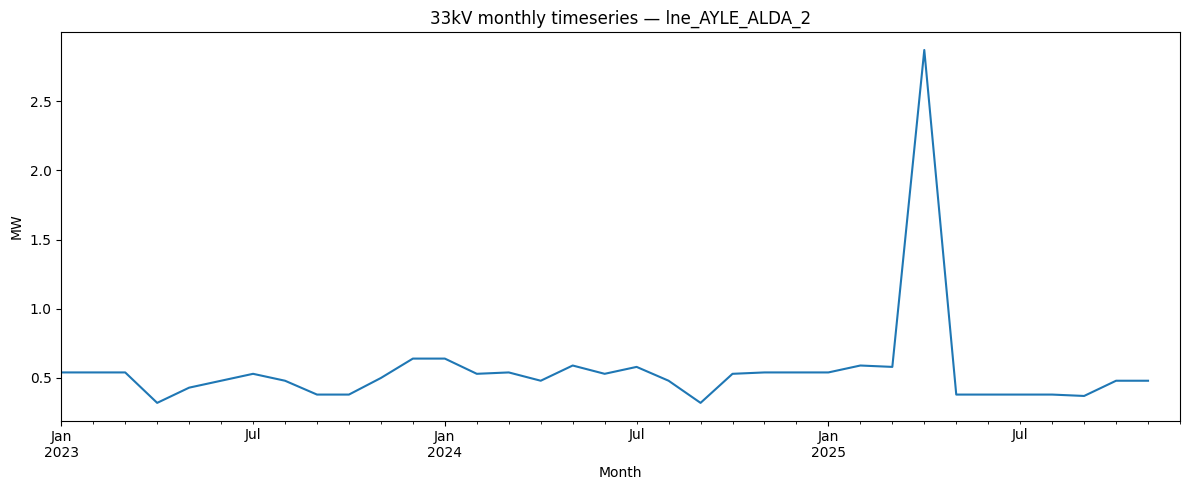

In [223]:
# 4. Line plot (pick a numeric column — e.g. max_mw / mean_mw / min_mw)
numeric_cols = df.select_dtypes(include="number").columns
ax = df["active_power_month_max_mw"].plot(
    figsize=(12, 5), title=f"33kV monthly timeseries — {circuit_id}"
)
ax.set_ylabel("MW")
ax.set_xlabel("Month")
plt.tight_layout()
plt.show()

---
## 6. Geospatial - Every Record Has `.geometry`

All geospatial records come back with normalised GeoJSON geometry — ready for mapping.

In [219]:
# Individual record geometries
from ukpyn import gis

substations = gis.get_primary_substations(licence_area="SPN", limit=5)

print(f"Primary substations (SPN): {substations.total_count}\n")
for rec in substations.records:
    name = rec.fields.get("sitefunctionallocation", "?")
    print(f"  {str(name):30s} → {rec.geometry}")

Primary substations (SPN): 270

  SPN-S000000008030              → {'type': 'Point', 'coordinates': [-0.370856, 51.412031]}
  SPN-S000000008063              → {'type': 'Point', 'coordinates': [1.409348, 51.342121]}
  SPN-S000000008133              → {'type': 'Point', 'coordinates': [0.490601, 51.176082]}
  SPN-S000000008147              → {'type': 'Point', 'coordinates': [1.103069, 51.299316]}
  SPN-S000000008150              → {'type': 'Point', 'coordinates': [0.049494, 50.801609]}


In [220]:
import json

# Export entire datasets as GeoJSON — ready for QGIS, Leaflet, Mapbox, etc.
geojson_bytes = gis.export_geojson("licence_boundaries", dimensions="2d")
geojson = json.loads(geojson_bytes)

print(f"GeoJSON type: {geojson['type']}")
print(f"Features: {len(geojson['features'])}\n")

for feat in geojson["features"]:
    props = feat.get("properties", {})
    geom_type = feat["geometry"]["type"]
    print(f"  {props.get('name', '?'):30s} — {geom_type}")

# Save for use in mapping tools
with open("licence_boundaries.geojson", "w") as f:
    json.dump(geojson, f)
print("\n✓ Saved to licence_boundaries.geojson — paste into geojson.io to view")

GeoJSON type: FeatureCollection
Features: 3

  EPN                            — Polygon
  LPN                            — Polygon
  SPN                            — Polygon

✓ Saved to licence_boundaries.geojson — paste into geojson.io to view


## Round Up

- Datasets are grouped by domain in orchestrators 

- Convencience Functions to support quicker queries

- You can build your own filtering through the WHERE clause


---

## Quick Reference

| Strategy question | Key datasets | Orchestrator |
|---|---|---|
| Is there capacity for heat pumps / EVs? | `headroom`, `by_local_authority` | `dfes` |
| What's the current peak demand? | `table_3a`, `table_3b` | `ltds` |
| What generation is already connected? | `ecr`, `ecr_small`, `table_5` | `ders`, `ltds` |
| Where are the substations? | `grid_primary_sites`, `secondary_sites` | `gis` |
| What reinforcement is planned? | `projects` | `ltds` |
| Which areas are constrained? | `dnoa`, `headroom` | `dnoa`, `dfes` |
| What flex services have been dispatched? | `dispatches`, `tenders` | `flexibility` |
| Where has generation been curtailed? | `events` | `curtailment` |
| What does the network look like on a map? | `hv_overhead_lines`, `licence_boundaries` | `gis` |
| What are the half-hourly power flows? | `primary_half_hourly_*`, `132kv_half_hourly` | `powerflow` |

## Get Started

- **Docs:** https://ukpn-dso.github.io/ukpyn/
- **PyPI:** https://pypi.org/project/ukpyn/
- **Install:** `pip install ukpyn`
- **Source:** https://github.com/UKPN-DSO/ukpyn